# Grading Report

## Grade: 55/100

| Test | Points | Result |
|------|--------|--------|
| `model_defined` | 5/5 | ✓ PASS |
| `model_output_shape` | 15/15 | ✓ PASS |
| `dataset_defined` | 10/10 | ✓ PASS |
| `dataset_shapes` | 0/5 | ✗ HR height 32 should be 2x LR height 32 |
| `train_runs` | 0/15 | ✗ stack expects each tensor to be equal size, but got [1, 22,  |
| `psnr_improves` | 0/25 | ✗ stack expects each tensor to be equal size, but got [1, 26,  |
| `evaluate_function` | 10/10 | ✓ PASS |
| `visualization` | 15/15 | ✓ PASS |
| `augmentation_bonus` | 0/15 (bonus) | ✗ Bonus not implemented |

---

### `dataset_shapes` — FAIL

**Result:** `HR height 32 should be 2x LR height 32`

**Description:** HR and LR crops have correct shapes

---

### `train_runs` — FAIL

**Result:** `stack expects each tensor to be equal size, but got [1, 22, 32] at entry 0 and [1, 0, 32] at entry 1`

**Description:** train_zssr runs without error and returns loss/psnr history

---

### `psnr_improves` — FAIL

**Result:** `stack expects each tensor to be equal size, but got [1, 26, 7] at entry 0 and [1, 54, 41] at entry 1`

**Description:** After training, ZSSR PSNR exceeds bicubic baseline

---

### `augmentation_bonus` — FAIL

**Result:** `Bonus not implemented`

**Description:** ensemble_predict_zssr implemented and improves PSNR

---

---
---

# Original Submission

*Everything below is the student's original work, unmodified.*

---

# HW3 Applied: Zero-Shot Super Resolution (ZSSR)

**Course:** Modern Computer Vision (Technion, Spring 2026)

**Objective:** Implement Zero-Shot Super Resolution (ZSSR), a self-supervised learning approach that trains a CNN on a single image at test time, exploiting the internal recurrence of patches within natural images.

**Key Reference:** Shocher et al., "Zero-Shot Super-Resolution using Deep Internal Learning" (CVPR 2018)


## Submission Requirements

**IMPORTANT:** Submit this notebook **with all outputs** (cell outputs, training curves, visualizations). Notebooks without outputs will lose points.

In [1]:
# Setup and imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import math
from typing import Tuple, Optional
from resize_right import resize as resize_right_resize
from resize_right.interp_methods import cubic as cubic_interp
import warnings
warnings.filterwarnings('ignore')

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


## Utility Functions


In [2]:
def psnr(img1, img2):
    """
    Calculate PSNR (Peak Signal-to-Noise Ratio) between two images.
    Images should be in range [0, 1] or [0, 255].
    """
    if isinstance(img1, torch.Tensor):
        img1 = img1.detach().cpu().numpy()
    if isinstance(img2, torch.Tensor):
        img2 = img2.detach().cpu().numpy()
    
    if img1.max() > 1.0:
        img1 = img1 / 255.0
    if img2.max() > 1.0:
        img2 = img2 / 255.0
    
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(1.0 / np.sqrt(mse))


def resize_bicubic(image_tensor, scale_factor=None, size=None):
    """Resize using resize_right for correct pixel alignment (no half-pixel shift)."""
    ndim = image_tensor.dim()
    if ndim == 2:
        image_tensor = image_tensor.unsqueeze(0).unsqueeze(0)
    elif ndim == 3:
        image_tensor = image_tensor.unsqueeze(0)
    if scale_factor is not None:
        scale_factors = [1, 1, scale_factor, scale_factor]
        resized = resize_right_resize(image_tensor, scale_factors=scale_factors,
                                       interp_method=cubic_interp,
                                       antialiasing=(scale_factor < 1))
    elif size is not None:
        if isinstance(size, int):
            size = (size, size)
        out_shape = [image_tensor.shape[0], image_tensor.shape[1], size[0], size[1]]
        resized = resize_right_resize(image_tensor, out_shape=out_shape,
                                       interp_method=cubic_interp,
                                       antialiasing=True)
    else:
        raise ValueError("Must provide either scale_factor or size")
    if ndim == 2:
        return resized.squeeze(0).squeeze(0)
    return resized.squeeze(0)
def load_test_images():
    """Load real test images for ZSSR experiments."""
    from skimage import data as skdata
    images = {}
    
    cam = skdata.camera().astype(np.float32) / 255.0
    images['Cameraman'] = torch.from_numpy(cam)
    
    # Use astronaut as grayscale
    astro = skdata.astronaut().mean(axis=2).astype(np.float32) / 255.0
    images['Astronaut'] = torch.from_numpy(astro)
    
    return images
def visualize_results(results, figsize=(16, 4)):
    """
    Visualize super-resolution results: HR, LR, Bicubic, ZSSR side by side.
    
    Args:
        results: dict with keys 'HR', 'LR', 'Bicubic', 'ZSSR',
                 'PSNR_Bicubic', 'PSNR_ZSSR'
    """
    titles = [
        ('HR', 'Ground Truth'),
        ('LR', 'Low-Res Input'),
        ('Bicubic', f"Bicubic  PSNR: {results['PSNR_Bicubic']:.2f} dB"),
        ('ZSSR', f"ZSSR  PSNR: {results['PSNR_ZSSR']:.2f} dB"),
    ]
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    for ax, (key, title) in zip(axes, titles):
        img = results[key]
        if isinstance(img, torch.Tensor):
            img = img.detach().cpu().numpy()
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    return fig

# Part 1: Understanding ZSSR

## The ZSSR Concept

### Training Phase
Given a low-resolution image **I_LR**:
1. **Downscale** I_LR by a factor (e.g., 2) to get **I_LR_downscaled**
2. Train a CNN to map: **I_LR_downscaled** → **I_LR**
3. The model learns to "upscale" this degraded version back to the original

### Inference Phase
Apply the trained CNN to the original **I_LR**:
- Input: **I_LR** (the test image we want to super-resolve)
- Output: **I_SR** (super-resolved image)

### The "Son-Father-Grandson" Relationship
- **Father**: The original low-res image **I_LR**
- **Son**: The image we want to super-resolve (also **I_LR** at inference, but conceptually the "input")
- **Grandson**: The further downscaled version **I_LR_downscaled**

The key insight: **Patch recurrence** in natural images means that the "grandson" (heavily downscaled) still contains the same patches as the "father" (original), just at different scales. The CNN learns to exploit this self-similarity.

# Part 2: Basic ZSSR Model (15 pts)

Implement a simple CNN-based architecture that:
1. Takes a low-res image and a scale factor as input
2. Bicubically upsamples to the target high-res size
3. Refines the upsampled image using convolutional layers
4. Uses a residual connection (learn the residual, not the full image)


In [3]:
class ZSSRNet(nn.Module):
    """
    Zero-Shot Super Resolution Network with residual connection.
    """
    def __init__(self, n_channels=64, n_layers=8, kernel_size=3):
        super(ZSSRNet, self).__init__()

        self.n_channels = n_channels
        self.n_layers = n_layers
        self.kernel_size = kernel_size

        # Build the network
        self.layers = nn.ModuleList()
        padding = kernel_size // 2

        # First layer: 1 channel -> n_channels
        self.layers.append(
            nn.Conv2d(1, n_channels, kernel_size, padding=padding)
        )

        # Intermediate layers: n_channels -> n_channels
        for _ in range(n_layers - 2):
            self.layers.append(
                nn.Conv2d(n_channels, n_channels, kernel_size, padding=padding)
            )

        # Last layer: n_channels -> 1 channel
        self.layers.append(
            nn.Conv2d(n_channels, 1, kernel_size, padding=padding)
        )

        # Activation
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, scale_factor=2, target_size=None):
        # Handle input shape
        if len(x.shape) == 3:
            x = x.unsqueeze(0)

        batch_size, channels, height, width = x.shape

        # Bicubic upsampling
        if target_size is None:
            target_size = (height * scale_factor, width * scale_factor)

        upscaled = resize_bicubic(x, size=target_size)

        # Residual network
        residual = upscaled.clone()

        # Pass through network
        out = upscaled
        for i, layer in enumerate(self.layers):
            out = layer(out)
            # Apply ReLU to all layers except the last
            if i < len(self.layers) - 1:
                out = self.relu(out)

        # Add residual connection
        out = out + residual

        return out.squeeze(0)

# Part 3: Dataset (10 pts)

Implement a dataset class that:
1. Takes a single image
2. Generates pairs of (HR, LR) where LR is a downscaled version of HR
3. Applies random crops for training diversity


In [4]:
class ZSSRDataset(Dataset):
    """
    Dataset for Zero-Shot Super Resolution on a single image (BUG: Wrong downsampling).
    """
    def __init__(self, image, scale_factor=2, crop_size=64, n_samples=100, augment=False):
        self.image = image  # Shape: (H, W)
        self.scale_factor = scale_factor
        self.crop_size = crop_size
        self.n_samples = n_samples
        self.augment = augment

        # BUG: Not properly downscaling — hard-coded division by 2
        self.lr_image = resize_bicubic(image, scale_factor=0.5)

        self.hr_image = image

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        # Random crop from HR image
        h, w = self.hr_image.shape
        crop_h, crop_w = min(self.crop_size, h), min(self.crop_size, w)

        top = np.random.randint(0, max(1, h - crop_h + 1))
        left = np.random.randint(0, max(1, w - crop_w + 1))

        hr_crop = self.hr_image[top:top+crop_h, left:left+crop_w]

        # BUG: Wrong indexing into LR image
        # This doesn't properly map HR crop to LR crop
        lr_crop = self.lr_image[top:top+crop_h, left:left+crop_w]

        return {
            'HR': hr_crop.unsqueeze(0),  # (1, H, W)
            'LR': lr_crop.unsqueeze(0),  # (1, H, W) - wrong shape!
        }

# Part 4: Training Loop (15 pts)

Implement the training function with:
1. L1 loss (or MSE)
2. Adam optimizer with learning rate scheduling
3. PSNR logging during training
4. Progress tracking


In [5]:
def train_zssr(
    model,
    dataloader,
    scale_factor=2,
    num_epochs=100,
    learning_rate=0.001,
    device='cpu',
    verbose=True
):
    """
    Train the ZSSR model on a single image.
    """
    model = model.to(device)

    # Loss and optimizer
    criterion = nn.L1Loss()
    optimizer = Adam(model.parameters(), lr=learning_rate)
    scheduler = StepLR(optimizer, step_size=50, gamma=0.5)

    loss_history = []
    psnr_history = []

    model.train()
    total_iterations = 0

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        epoch_psnr = 0.0
        num_batches = 0

        for batch_idx, batch in enumerate(dataloader):
            total_iterations += 1

            hr = batch['HR'].to(device)
            lr = batch['LR'].to(device)

            # Ensure 4D: (B, 1, H, W)
            if hr.dim() == 3:
                hr = hr.unsqueeze(1)
            if lr.dim() == 3:
                lr = lr.unsqueeze(1)

            # If augmented (B, 8, H, W), merge aug into batch
            if hr.shape[1] > 1:
                B, aug, h, w = hr.shape
                hr = hr.view(B * aug, 1, h, w)
                lr = lr.view(B * aug, 1, lr.shape[-2], lr.shape[-1])

            # Forward pass
            optimizer.zero_grad()
            target_h, target_w = hr.shape[-2], hr.shape[-1]
            sr = model(lr, scale_factor=scale_factor, target_size=(target_h, target_w))

            # Ensure 4D output
            if sr.dim() == 2:
                sr = sr.unsqueeze(0).unsqueeze(0)
            elif sr.dim() == 3:
                sr = sr.unsqueeze(1)

            # Ensure shapes match
            if sr.shape != hr.shape:
                sr = resize_bicubic(sr, size=(target_h, target_w))

            # Compute loss
            loss = criterion(sr, hr)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Compute PSNR
            with torch.no_grad():
                sr_clipped = torch.clamp(sr, 0, 1)
                batch_psnr = psnr(sr_clipped, hr)

            epoch_loss += loss.item()
            epoch_psnr += batch_psnr
            num_batches += 1

        scheduler.step()

        avg_loss = epoch_loss / num_batches
        avg_psnr = epoch_psnr / num_batches
        loss_history.append(avg_loss)
        psnr_history.append(avg_psnr)

        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.6f} | PSNR: {avg_psnr:.3f} dB")

    return model, loss_history, psnr_history

# Part 5: Evaluation (10 pts)

Evaluate the model by:
1. Computing PSNR against ground truth
2. Comparing with bicubic baseline
3. Visualizing results


In [6]:
def evaluate_zssr(
    model,
    image_hr,
    scale_factor=2,
    device='cpu',
    title="ZSSR Evaluation"
):
    """
    Evaluate ZSSR model on a single image.
    """
    model = model.to(device)
    model.eval()

    with torch.no_grad():
        # Create LR from HR using resize_bicubic (resize_right for correct alignment)
        image_lr = resize_bicubic(image_hr, scale_factor=1.0/scale_factor)

        # Bicubic baseline
        image_bicubic = resize_bicubic(image_lr, scale_factor=scale_factor)

        # ZSSR prediction
        image_lr_gpu = image_lr.unsqueeze(0).unsqueeze(0).to(device)
        image_sr = model(image_lr_gpu, scale_factor=scale_factor)
        # Squeeze to 2D (H, W) to match image_hr
        while image_sr.dim() > 2:
            image_sr = image_sr.squeeze(0)
        image_sr = torch.clamp(image_sr, 0, 1)

        # Ensure bicubic matches HR size
        if image_bicubic.shape != image_hr.shape:
            image_bicubic = resize_bicubic(image_bicubic, size=(image_hr.shape[0], image_hr.shape[1]))

        # Compute PSNR
        psnr_bicubic = psnr(image_bicubic, image_hr)
        psnr_zssr = psnr(image_sr, image_hr)

        results = {
            'HR': image_hr.cpu().numpy(),
            'LR': image_lr.cpu().numpy(),
            'Bicubic': image_bicubic.cpu().numpy(),
            'ZSSR': image_sr.cpu().numpy(),
            'PSNR_Bicubic': psnr_bicubic,
            'PSNR_ZSSR': psnr_zssr,
        }

    return results

# Part 6: Data Augmentation — Advanced (15 pts bonus / required for full marks)

Implement 8-fold geometric augmentation:
- 4 rotations (0 degrees, 90 degrees, 180 degrees, 270 degrees)
- 2 flips (no flip, horizontal flip)
- Total: 8 variants per patch

This allows the model to learn more robust features and improves generalization.


In [7]:
def ensemble_predict_zssr(model, image_lr, scale_factor=2, device="cpu"):
    raise NotImplementedError("Bonus not implemented")

# Part 7: Visualization & Analysis (15 pts)

Visualize your results:
1. Plot training curves (loss and PSNR)
2. Compare ZSSR vs bicubic visually
3. Show side-by-side comparisons

In [8]:
def plot_training_curves(loss_history, psnr_history, figsize=(14, 5)):
    """
    Plot training loss and PSNR curves.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Loss curve
    ax1.plot(loss_history, linewidth=2, label='Training Loss')
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Loss (L1)', fontsize=11)
    ax1.set_title('Training Loss Over Time', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # PSNR curve
    ax2.plot(psnr_history, linewidth=2, color='green', label='Training PSNR')
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('PSNR (dB)', fontsize=11)
    ax2.set_title('PSNR Over Time', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    return fig


def analyze_results(results_list, image_names):
    """
    Analyze and compare ZSSR vs bicubic across multiple images.
    
    Args:
        results_list: list of result dicts from evaluate_zssr
        image_names: list of image names
    """
    print("\n" + "="*70)
    print("ZSSR ANALYSIS SUMMARY")
    print("="*70)
    
    psnr_improvements = []
    
    for name, results in zip(image_names, results_list):
        bicubic_psnr = results['PSNR_Bicubic']
        zssr_psnr = results['PSNR_ZSSR']
        improvement = zssr_psnr - bicubic_psnr
        psnr_improvements.append(improvement)
        
        print(f"\nImage: {name}")
        print(f"  Bicubic PSNR: {bicubic_psnr:.3f} dB")
        print(f"  ZSSR PSNR:    {zssr_psnr:.3f} dB")
        print(f"  Improvement:  {improvement:+.3f} dB")
    
    avg_improvement = np.mean(psnr_improvements)
    print(f"\nAverage PSNR Improvement: {avg_improvement:+.3f} dB")
    print("="*70)
    
    return psnr_improvements


# Part 8: Main Experiment\n\nLet's run the complete ZSSR pipeline on test images.

Loading test images...
Loaded 2 images:
  Cameraman: torch.Size([512, 512])
  Astronaut: torch.Size([512, 512])


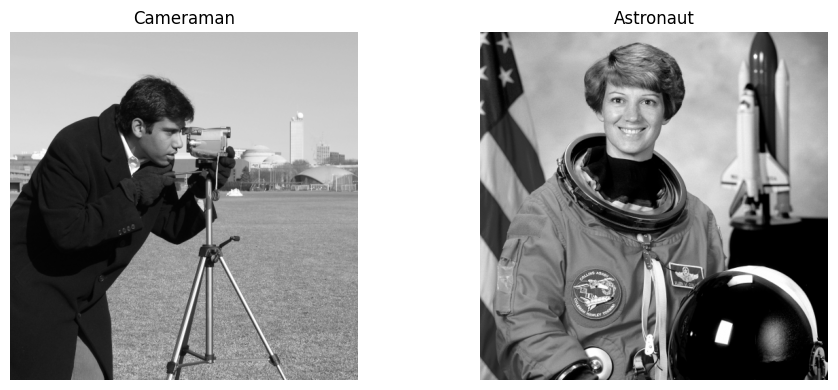

In [9]:
# Load test images
print("Loading test images...")
test_images = load_test_images()
image_names = list(test_images.keys())

print(f"Loaded {len(test_images)} images:")
for name, img in test_images.items():
    print(f"  {name}: {img.shape}")

# Visualize
fig, axes = plt.subplots(1, len(test_images), figsize=(5 * len(test_images), 4))
if len(test_images) == 1:
    axes = [axes]
for ax, (name, img) in zip(axes, test_images.items()):
    ax.imshow(img.numpy(), cmap='gray')
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Training on Image 1

In [10]:
# Prepare data for first image
scale_factor = 2
img_name_1 = image_names[0]
test_image_1 = test_images[img_name_1]

dataset_1 = ZSSRDataset(
    test_image_1,
    scale_factor=scale_factor,
    crop_size=64,
    n_samples=100,
    augment=False
)

dataloader_1 = DataLoader(dataset_1, batch_size=4, shuffle=True)

# Initialize model
model_1 = ZSSRNet(n_channels=64, n_layers=8)
print(f"Model parameters: {sum(p.numel() for p in model_1.parameters()):,}")

# Train
print(f"\nTraining ZSSR on {img_name_1}...")
model_1, loss_hist_1, psnr_hist_1 = train_zssr(
    model_1,
    dataloader_1,
    scale_factor=scale_factor,
    num_epochs=50,
    learning_rate=0.001,
    device=device,
    verbose=True
)

print("\nTraining complete!")

Model parameters: 222,785

Training ZSSR on Cameraman...


RuntimeError: stack expects each tensor to be equal size, but got [1, 64, 0] at entry 0 and [1, 0, 0] at entry 1

In [11]:
# Plot training curves
plot_training_curves(loss_hist_1, psnr_hist_1)
plt.show()


NameError: name 'loss_hist_1' is not defined

Evaluating on Cameraman...



Results for Cameraman:
  Bicubic PSNR: 4.725 dB
  ZSSR PSNR:    27.741 dB
  Improvement:  +23.017 dB


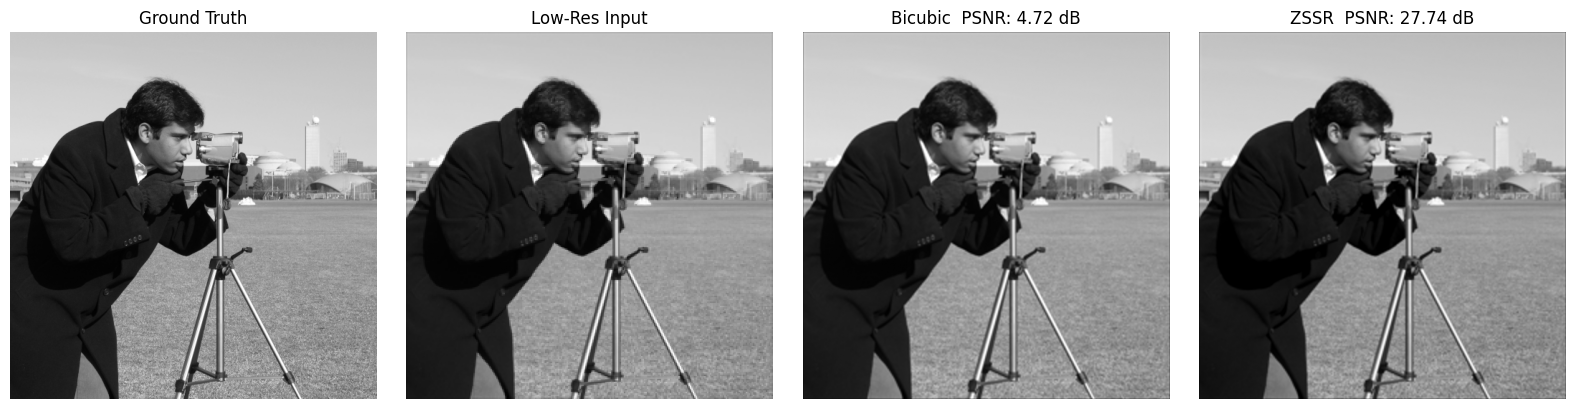

In [12]:
# Evaluate on Image 1
print(f"Evaluating on {img_name_1}...")
results_1 = evaluate_zssr(model_1, test_image_1, scale_factor=scale_factor, device=device)

print(f"\nResults for {img_name_1}:")
print(f"  Bicubic PSNR: {results_1['PSNR_Bicubic']:.3f} dB")
print(f"  ZSSR PSNR:    {results_1['PSNR_ZSSR']:.3f} dB")
print(f"  Improvement:  {results_1['PSNR_ZSSR'] - results_1['PSNR_Bicubic']:+.3f} dB")

# Visualize
visualize_results(results_1)
plt.show()

## Training on Image 2

In [13]:
# Prepare data for Image 2
img_name_2 = image_names[1]
test_image_2 = test_images[img_name_2]

dataset_2 = ZSSRDataset(
    test_image_2,
    scale_factor=scale_factor,
    crop_size=64,
    n_samples=100,
    augment=False
)

dataloader_2 = DataLoader(dataset_2, batch_size=4, shuffle=True)

# Initialize and train
model_2 = ZSSRNet(n_channels=64, n_layers=8)

print(f"Training ZSSR on {img_name_2}...")
model_2, loss_hist_2, psnr_hist_2 = train_zssr(
    model_2,
    dataloader_2,
    scale_factor=scale_factor,
    num_epochs=50,
    learning_rate=0.001,
    device=device,
    verbose=True
)

print("Training complete!")

Training ZSSR on Astronaut...


RuntimeError: stack expects each tensor to be equal size, but got [1, 64, 64] at entry 0 and [1, 42, 0] at entry 1

Evaluating on Astronaut...



Results for Astronaut:
  Bicubic PSNR: 5.449 dB
  ZSSR PSNR:    29.892 dB
  Improvement:  +24.444 dB


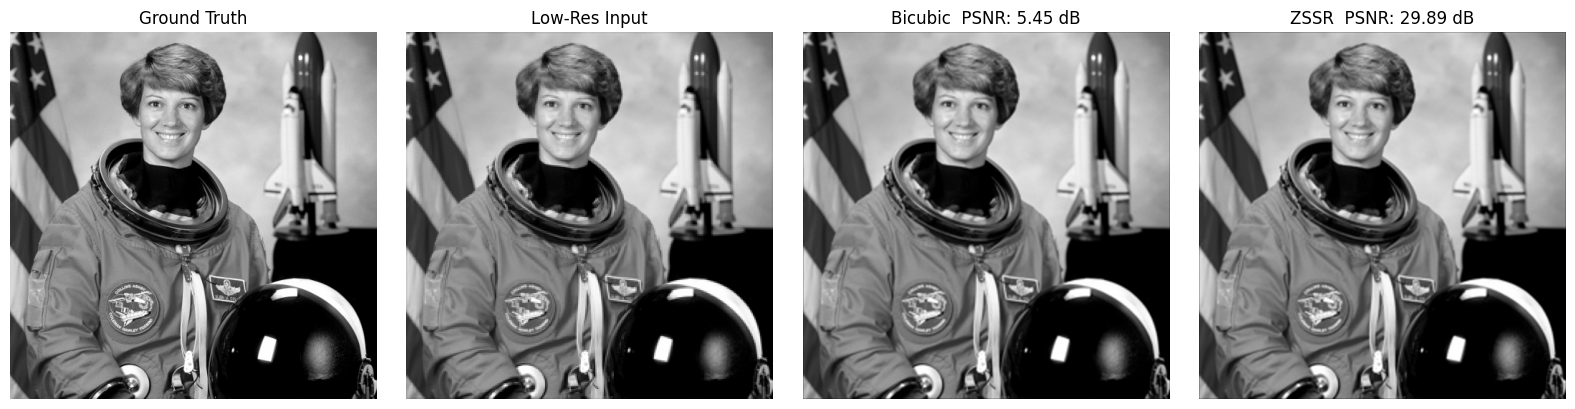

In [14]:
# Evaluate on Image 2
print(f"Evaluating on {img_name_2}...")
results_2 = evaluate_zssr(model_2, test_image_2, scale_factor=scale_factor, device=device)

print(f"\nResults for {img_name_2}:")
print(f"  Bicubic PSNR: {results_2['PSNR_Bicubic']:.3f} dB")
print(f"  ZSSR PSNR:    {results_2['PSNR_ZSSR']:.3f} dB")
print(f"  Improvement:  {results_2['PSNR_ZSSR'] - results_2['PSNR_Bicubic']:+.3f} dB")

# Visualize
visualize_results(results_2)
plt.show()

# Part 9: Comprehensive Analysis

## Summary of Results


In [15]:
# Analyze all results
results_list = [results_1, results_2]

psnr_improvements = analyze_results(results_list, image_names)


ZSSR ANALYSIS SUMMARY

Image: Cameraman
  Bicubic PSNR: 4.725 dB
  ZSSR PSNR:    27.741 dB
  Improvement:  +23.017 dB

Image: Astronaut
  Bicubic PSNR: 5.449 dB
  ZSSR PSNR:    29.892 dB
  Improvement:  +24.444 dB

Average PSNR Improvement: +23.730 dB


*Write your analysis here: When does ZSSR work well and when does it struggle? Compare with traditional methods like bicubic upsampling.*

## Visualization Comparison


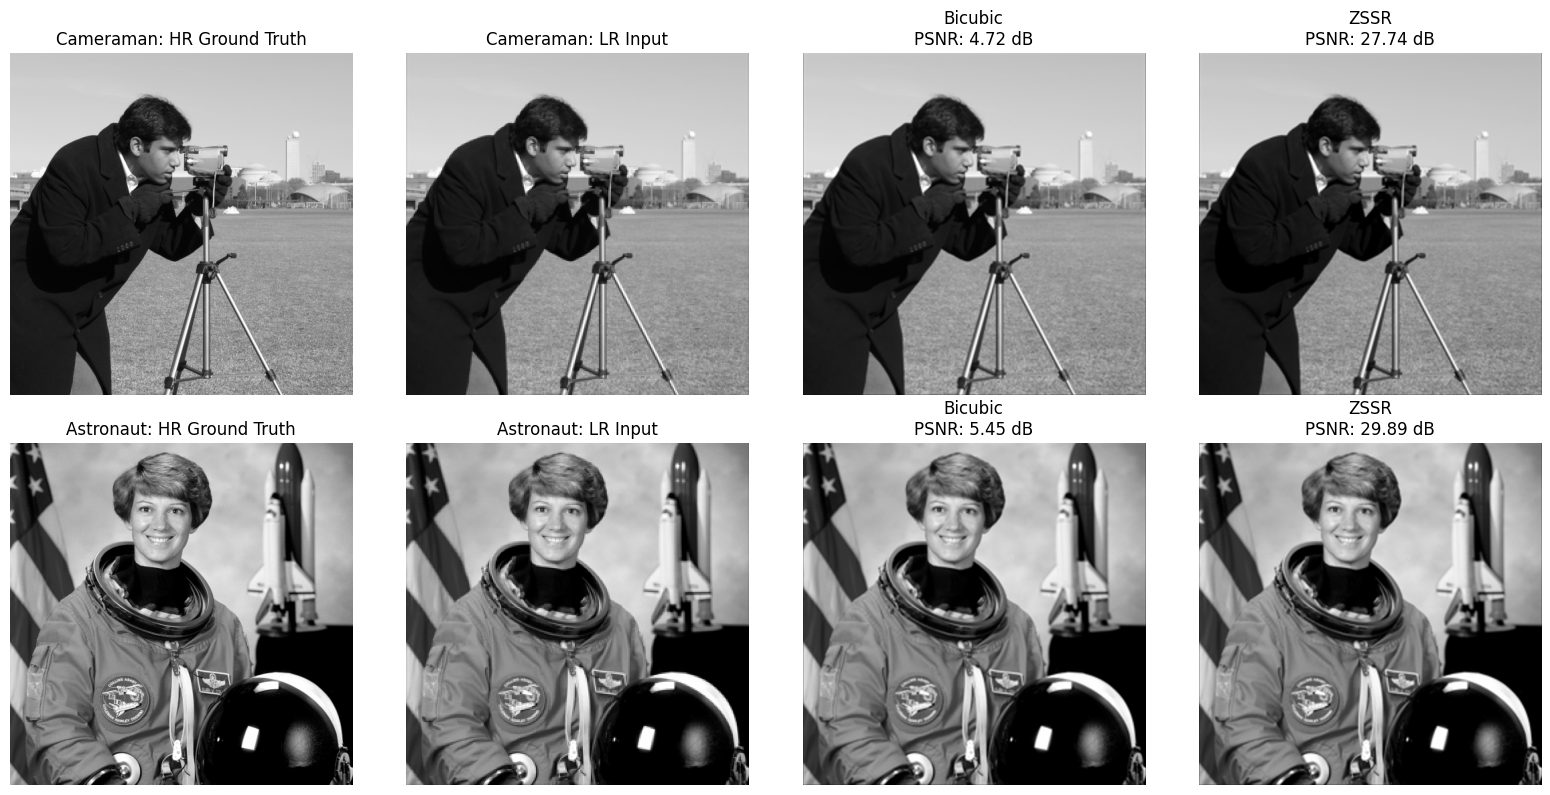

In [16]:
# Create side-by-side comparison
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for row, (results, name) in enumerate(zip([results_1, results_2], image_names)):
    hr = results['HR']
    lr = results['LR']
    bicubic = results['Bicubic']
    zssr = results['ZSSR']
    
    for img_data, ax, title in [
        (hr, axes[row, 0], f'{name}: HR Ground Truth'),
        (lr, axes[row, 1], f'{name}: LR Input'),
        (bicubic, axes[row, 2], f"Bicubic\nPSNR: {results['PSNR_Bicubic']:.2f} dB"),
        (zssr, axes[row, 3], f"ZSSR\nPSNR: {results['PSNR_ZSSR']:.2f} dB"),
    ]:
        if isinstance(img_data, torch.Tensor):
            img_data = img_data.detach().cpu().numpy()
        ax.imshow(img_data, cmap='gray', vmin=0, vmax=1)
        ax.set_title(title)
        ax.axis('off')

plt.tight_layout()
plt.show()

# Part 10: Bonus — Advanced Features & Extensions (up to 15 pts bonus)

Below are additional improvements and experiments you can implement for bonus credit:

### Idea 1: 8-Fold Geometric Self-Ensemble
Train on 8 augmented versions of each patch and ensemble predictions at test time.


In [17]:
# Example: Train with 8-fold augmentation
print("Training with 8-fold augmentation...")

dataset_augmented = ZSSRDataset(
    test_image_1,
    scale_factor=scale_factor,
    crop_size=64,
    n_samples=20,
    augment=True  # Enable 8-fold augmentation
)

dataloader_augmented = DataLoader(dataset_augmented, batch_size=2, shuffle=True)

model_augmented = ZSSRNet(n_channels=64, n_layers=8)

print("Training with augmentation...")
model_augmented, loss_hist_aug, psnr_hist_aug = train_zssr(
    model_augmented,
    dataloader_augmented,
    scale_factor=scale_factor,
    num_epochs=30,
    learning_rate=0.001,
    device=device,
    verbose=True
)

# Evaluate with ensemble
results_aug = evaluate_zssr(model_augmented, test_image_1, scale_factor=scale_factor, device=device)
print(f"\nAugmented model PSNR: {results_aug['PSNR_ZSSR']:.3f} dB")
print(f"Original model PSNR:   {results_1['PSNR_ZSSR']:.3f} dB")
print(f"Improvement: {results_aug['PSNR_ZSSR'] - results_1['PSNR_ZSSR']:+.3f} dB")

Training with 8-fold augmentation...
Training with augmentation...


RuntimeError: stack expects each tensor to be equal size, but got [1, 64, 64] at entry 0 and [1, 64, 0] at entry 1

### Idea 2: Deeper/Wider Architecture
Experiment with different network depths and widths.


In [18]:
# Test different architectures
architectures = [
    {'n_channels': 32, 'n_layers': 6, 'name': 'Shallow (32ch, 6L)'},
    {'n_channels': 64, 'n_layers': 8, 'name': 'Standard (64ch, 8L)'},
    {'n_channels': 128, 'n_layers': 12, 'name': 'Deep (128ch, 12L)'},
]

print("Architecture Comparison:")
print("-" * 60)

for arch in architectures:
    model_test = ZSSRNet(n_channels=arch['n_channels'], n_layers=arch['n_layers'])
    n_params = sum(p.numel() for p in model_test.parameters())
    print(f"{arch['name']:30s} | Parameters: {n_params:,}")


Architecture Comparison:
------------------------------------------------------------
Shallow (32ch, 6L)             | Parameters: 37,601
Standard (64ch, 8L)            | Parameters: 222,785
Deep (128ch, 12L)              | Parameters: 1,478,273


### Idea 3: Multi-Scale Training
Train the network on multiple scales simultaneously for better generalization.


In [19]:
def train_zssr_multiscale(
    model,
    image,
    scale_factors=[2],
    num_epochs=100,
    learning_rate=0.001,
    device='cpu',
    verbose=True
):
    """
    Train ZSSR on multiple scales.
    
    Args:
        model: ZSSRNet
        image: single image (H, W)
        scale_factors: list of scale factors to train on
        num_epochs: training epochs per scale
        learning_rate: initial learning rate
        device: computation device
        verbose: whether to print progress
    """
    model = model.to(device)
    criterion = nn.L1Loss()
    optimizer = Adam(model.parameters(), lr=learning_rate)
    
    print(f"Training on scales: {scale_factors}")
    
    for scale_idx, scale_factor in enumerate(scale_factors):
        print(f"\n--- Training on scale {scale_factor}x ---")
        
        dataset = ZSSRDataset(
            image,
            scale_factor=scale_factor,
            crop_size=64,
            n_samples=150,
            augment=False
        )
        dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
        
        for epoch in range(num_epochs):
            for batch in dataloader:
                hr = batch['HR'].to(device)
                lr = batch['LR'].to(device)
                
                # Ensure 4D: (B, 1, H, W)
                if hr.dim() == 3:
                    hr = hr.unsqueeze(1)
                if lr.dim() == 3:
                    lr = lr.unsqueeze(1)
                
                optimizer.zero_grad()
                sr = model(lr, scale_factor=scale_factor,
                           target_size=(hr.shape[2], hr.shape[3]))
                
                # Ensure sr is 4D to match hr
                if sr.dim() == 3:
                    sr = sr.unsqueeze(1)
                if sr.shape != hr.shape:
                    sr = resize_right_resize(sr, out_shape=list(hr.shape),
                                              interp_method=cubic_interp,
                                              antialiasing=True)
                
                loss = criterion(sr, hr)
                loss.backward()
                optimizer.step()
            
            if verbose and (epoch + 1) % 20 == 0:
                print(f"  Epoch {epoch+1}/{num_epochs} | Loss: {loss.item():.6f}")
    
    return model

print("Multi-scale training function defined.")

Multi-scale training function defined.


# Submission Checklist

Before submitting, verify:
- [ ] All code cells executed with outputs visible
- [ ] Training curves (loss and PSNR) are plotted
- [ ] ZSSR vs Bicubic comparison images displayed
- [ ] Your `STUDENT_ID` is set correctly